# Flat Surface Analysis

Loads TensorBoard scalar data from `runs/{FOLDER_NAME}/{exp_group}/{i}/` and plots
metrics aggregated across the numbered runs (mean line + 95% confidence band).

Data loading lives in `data_loader.py`; plotting in `plot_tools.py`. This notebook
only sets parameters and renders outputs.

## 1. Imports

In [20]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# The utility modules (data_loader.py, plot_tools.py) live next to this notebook
# in data_analysis/. Make them importable whether the kernel starts in
# data_analysis/ or the repo root by walking up from the cwd to find them.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (os.path.join(d, "data_analysis"), d):
            if os.path.isfile(os.path.join(cand, "data_loader.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import importlib
import data_loader as dl   # data loading + reduction (single source of truth)
import plot_tools as pt    # plotting + styling (single source of truth)

# Force a fresh load from disk every time this cell runs, so edits to data_loader.py /
# plot_tools.py (display names, colors, loaders) take effect WITHOUT restarting the kernel.
# Reload data_loader FIRST — plot_tools imports it, so it must re-bind the updated module.
importlib.reload(dl)
importlib.reload(pt)

<module 'plot_tools' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/plot_tools.py'>

## 2. Global parameters

Folder, CI width, x-axis, output folder, and the shared `STYLE` object.

In [21]:
# Root folder that contains the experiment-group sub-folders (runs/{FOLDER_NAME}).
PROJECT_ROOT = dl.find_project_root()
RUNS_ROOT = dl.runs_root()
# --- Data source. Set WANDB_PROJECT + WANDB_TAG to pull runs from Weights & Biases:
# downloaded ONCE into runs/{WANDB_PROJECT}_{WANDB_TAG}/ (cached — the load cell below skips
# groups already present, so this notebook AND the other analysis notebook reuse the same data).
# Set WANDB_PROJECT/WANDB_TAG = None to load a local LOCAL_FOLDER instead.
WANDB_PROJECT = "surface_baselines"
WANDB_TAG     = "double-pace_mem-Fix"
WANDB_ENTITY  = "hur"
LOCAL_FOLDER  = "" #"ent_rotKP_test"  # used only when WANDB_PROJECT/TAG are None
FOLDER_NAME   = f"{WANDB_PROJECT}_{WANDB_TAG}" if (WANDB_PROJECT and WANDB_TAG) else LOCAL_FOLDER

# Confidence band: mean +/- CI_Z * SEM. 1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per group, ranked by each run's peak SUCCESS_METRIC.
# -1 keeps all runs.
TOP_N = 1
SUCCESS_METRIC = "Episode / Success rate"

# Shared x-axis for every time-series plot. XLIM is (min, max) or None.
XLABEL = "Env Steps"
XLIM = (0, 81001)

# One dated plots folder per run (re-running same day overwrites):
# runs/{FOLDER_NAME}/plots_{date}/{name}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_{datetime.now().strftime('%Y%m%d')}")

# Styling/context object threaded through every plot call. Display names + colors
# default to the glued_rot_rew controller ablation (see plot_tools); override
# STYLE.display_names / STYLE.group_colors here for a different run set.
STYLE = pt.PlotStyle(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)
STEP_CEILING = STYLE.step_ceiling

## 3. Load data

`DATA = { exp_group: [ {tag: (steps, values)}, ... one dict per run ] }`.

In [22]:
# Pull from wandb into runs/{FOLDER_NAME}/ (download once; cached). No-op for a local FOLDER_NAME.
if WANDB_PROJECT and WANDB_TAG:
    dl.download_wandb_data(WANDB_PROJECT, WANDB_TAG, entity=WANDB_ENTITY, root=RUNS_ROOT)
DATA = dl.load_data(FOLDER_NAME, RUNS_ROOT)
DATA = dl.filter_top_n(DATA, TOP_N, SUCCESS_METRIC, STEP_CEILING)

[wandb-dl] 21 run(s) in hur/surface_baselines tagged 'double-pace_mem-Fix' -> 7 group(s) -> /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix
[wandb-dl]   1_fixed: cached (3 runs), skip
[wandb-dl]   2_VICES: cached (3 runs), skip
[wandb-dl]   4_GAS_fixed_rot: cached (3 runs), skip
[wandb-dl]   5_GAS: cached (3 runs), skip
[wandb-dl]   6_dynm_fixed_rot: cached (3 runs), skip
[wandb-dl]   7_GAS_dyn: cached (3 runs), skip
[wandb-dl]   8_GAS_geo: cached (3 runs), skip
1_fixed: 3 runs loaded
2_VICES: 3 runs loaded
4_GAS_fixed_rot: 3 runs loaded
5_GAS: 3 runs loaded
6_dynm_fixed_rot: 3 runs loaded
7_GAS_dyn: 3 runs loaded
8_GAS_geo: 3 runs loaded
1_fixed: kept top 1/3 runs (by Episode / Success rate)
2_VICES: kept top 1/3 runs (by Episode / Success rate)
4_GAS_fixed_rot: kept top 1/3 runs (by Episode / Success rate)
5_GAS: kept top 1/3 runs (by Episode / Success rate)
6_dynm_fixed_rot: kept top 1/3 runs (by Episode / Success rate)
7_GAS_dyn: kept top

## 4. Best-point summary table (LaTeX)

In [23]:
# Best-point summary table (LaTeX). For each run, freeze the step where
# SELECTION_METRIC peaks (within the XLIM ceiling) and read every TABLE_METRIC
# there; report mean +/- 95% CI across a method's runs. Best per column is bolded.
SELECTION_METRIC = "Episode / Success rate"

# One dict per column: tag, header, higher_is_better, unit (LaTeX, escape % as
# \\%), scale (e.g. 100 for percent), decimals (defaults to DEFAULT_DECIMALS).
TABLE_METRICS = [
    {"tag": "Episode / Success rate",       "header": "Success Rate",    "higher_is_better": True,  "unit": "\\%",    "scale": 100, "decimals": 1},
    #{"tag": "success_times",                "header": "Success Time",    "higher_is_better": False, "unit": "steps", "scale": 1,   "decimals": 1},
    {"tag": "Reward / Total reward (mean)", "header": "Total Reward",    "higher_is_better": True,  "unit": "",      "scale": 1,   "decimals": 1},
    #{"tag": "logs_rew/contact_penalty",     "header": "Contact Penalty", "higher_is_better": False, "unit": "",      "scale": 1,   "decimals": 2},
    {"tag": "drag_performance/keypoints_achieved_mean", "header": "Keypoints",    "higher_is_better": True,  "unit": "\\%",      "scale": 100/60,   "decimals": 1},
    {"tag": "drag_performance/force_mean", "header": "Force RMSE",    "higher_is_better": False,  "unit": "N",      "scale": 1,   "decimals": 1, "offset": 5.0, "rms": True},
    {"tag": "drag_performance/theta_mean", "header": "Angle RMSE",    "higher_is_better": False,  "unit": "\^{\circ}",      "scale": 1,   "decimals": 1, "offset": 10.0, "rms": True},
    {"tag": "drag_performance/speed_d_mean", "header": "Speed RMSE",    "higher_is_better": False,  "unit": "cm/s",      "scale": 100,   "decimals": 1, "offset": 0.05, "rms": True},
]

# Row order (display names OR raw folders). Only loaded methods appear.
ROW_ORDER = ["Fixed", "VICES", "Ours (GT Dyn-Rot)", "Ours (GT Geo-Rot)", "Ours (No-Losses)", "Ours (Dyn-Loss)", "Ours (Geo-Loss)"]
DEFAULT_DECIMALS = 3

TABLE_GROUPS = pt.resolve_row_order(DATA, ROW_ORDER, STYLE)
latex = pt.build_latex_table(DATA, SELECTION_METRIC, TABLE_METRICS, TABLE_GROUPS,
                             STYLE, default_decimals=DEFAULT_DECIMALS)
print(latex)

% Requires \usepackage{booktabs} in your preamble.
\begin{tabular}{lcccccc}
\toprule
Method & Success Rate (\%) $\uparrow$ & Total Reward $\uparrow$ & Keypoints (\%) $\uparrow$ & Force RMSE (N) $\downarrow$ & Angle RMSE (\^{\circ}) $\downarrow$ & Speed RMSE (cm/s) $\downarrow$ \\
\midrule
Fixed & $6.6 \pm 0.0$ & $721.3 \pm 0.0$ & $57.6 \pm 0.0$ & $0.8 \pm 0.0$ & $0.8 \pm 0.0$ & $2.5 \pm 0.0$ \\
VICES & $\mathbf{29.1 \pm 0.0}$ & $\mathbf{887.8 \pm 0.0}$ & $\mathbf{77.7 \pm 0.0}$ & $0.2 \pm 0.0$ & $1.3 \pm 0.0$ & $1.6 \pm 0.0$ \\
Ours (GT Dyn-Rot) & $28.0 \pm 0.0$ & $872.6 \pm 0.0$ & $74.9 \pm 0.0$ & $\mathbf{0.1 \pm 0.0}$ & $\mathbf{0.3 \pm 0.0}$ & $1.7 \pm 0.0$ \\
Ours (GT Geo-Rot) & $27.0 \pm 0.0$ & $862.6 \pm 0.0$ & $76.4 \pm 0.0$ & $0.4 \pm 0.0$ & $1.4 \pm 0.0$ & $1.8 \pm 0.0$ \\
Ours (No-Losses) & $19.3 \pm 0.0$ & $838.1 \pm 0.0$ & $73.4 \pm 0.0$ & $1.0 \pm 0.0$ & $0.9 \pm 0.0$ & $2.2 \pm 0.0$ \\
Ours (Dyn-Loss) & $27.7 \pm 0.0$ & $845.0 \pm 0.0$ & $76.3 \pm 0.0$ & $0.6 \pm 0.0$ & 

## 5. Success rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix/plots_20260721/Episode_Success rate.svg


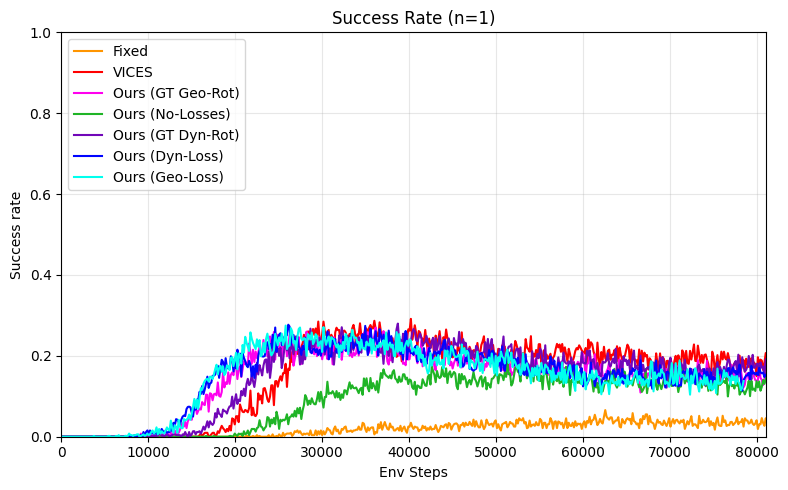

In [24]:
metric = 'Episode / Success rate'
ylabel = 'Success rate'
title = 'Success Rate (Best)'
legend_loc = 'upper left'
ylim = (0, 1.0)

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 5b. Success rate (smoothed)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix/plots_20260721/Episode_Success rate (smoothed).svg


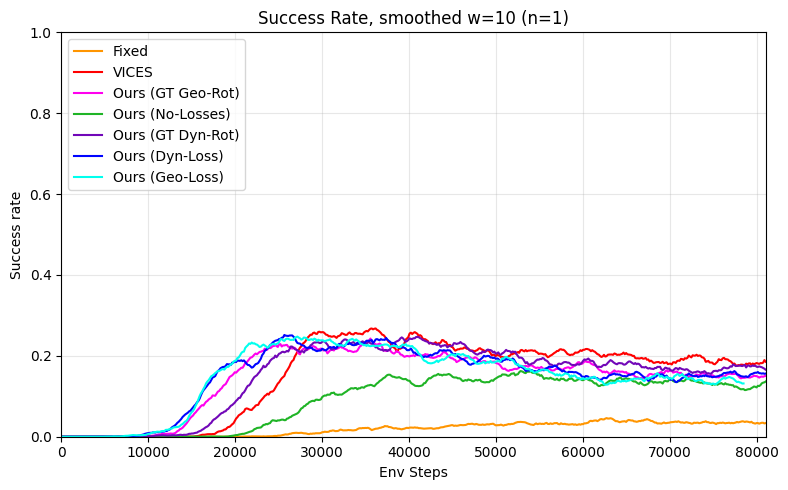

In [25]:
# Same success-rate data, but each run's curve is passed through a centered
# moving average first so the lines are readable. SMOOTH_WINDOW = 1 disables it.
SMOOTH_WINDOW = 10

metric = "Episode / Success rate"
ylabel = "Success rate"
title = f"Success Rate, smoothed w={SMOOTH_WINDOW} (Best)"
legend_loc = "upper left"
ylim = (0, 1.0)

smoothed = dl.smooth_data(DATA, metric, SMOOTH_WINDOW)
ax = pt.plot_metric(smoothed, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric + " (smoothed)", STYLE)
plt.show()

## 6. Total reward

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix/plots_20260721/Reward_Total reward (mean).svg


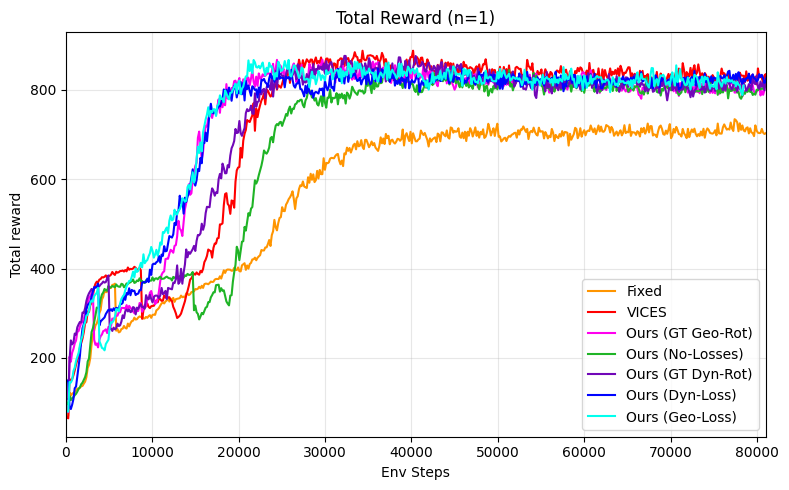

In [26]:
metric = 'Reward / Total reward (mean)'
ylabel = 'Total reward'
title = 'Total Reward (n=3)'
legend_loc = 'best'
ylim = None

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## 8. Success times

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix/plots_20260721/success_times.svg


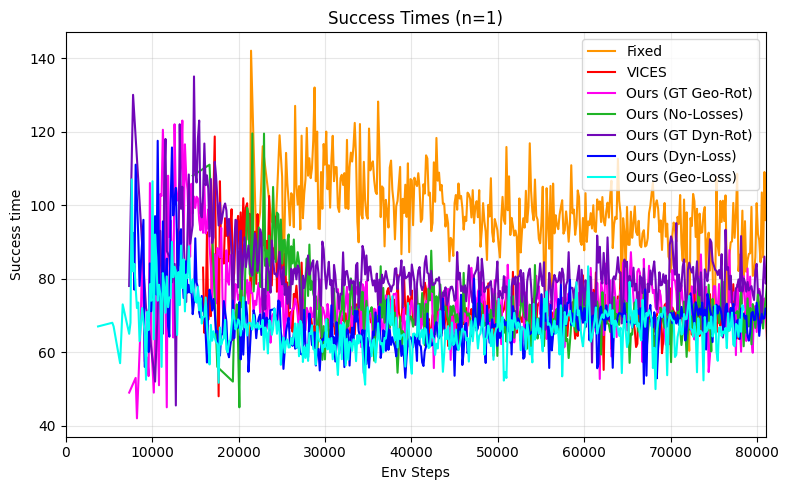

In [27]:
metric = 'success_times'
ylabel = 'Success time'
title = 'Success Times (n=3)'
legend_loc = 'best'
ylim = None

ax = pt.plot_metric(DATA, metric, ylabel, title, STYLE,
                    legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
pt.save_plot(ax.figure, metric, STYLE)
plt.show()

## Drag tracking RMSE bar charts

One subplot per drag metric: bars = methods, height = the Block-4 reduction (RMS error vs target for force/angle/speed; % keypoints achieved), error bars = 95% CI. Reuses the Block-4 `TABLE_METRICS` specs so the bars and the summary table agree.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_double-pace_mem-Fix/plots_20260721/drag_rmse_bars.svg


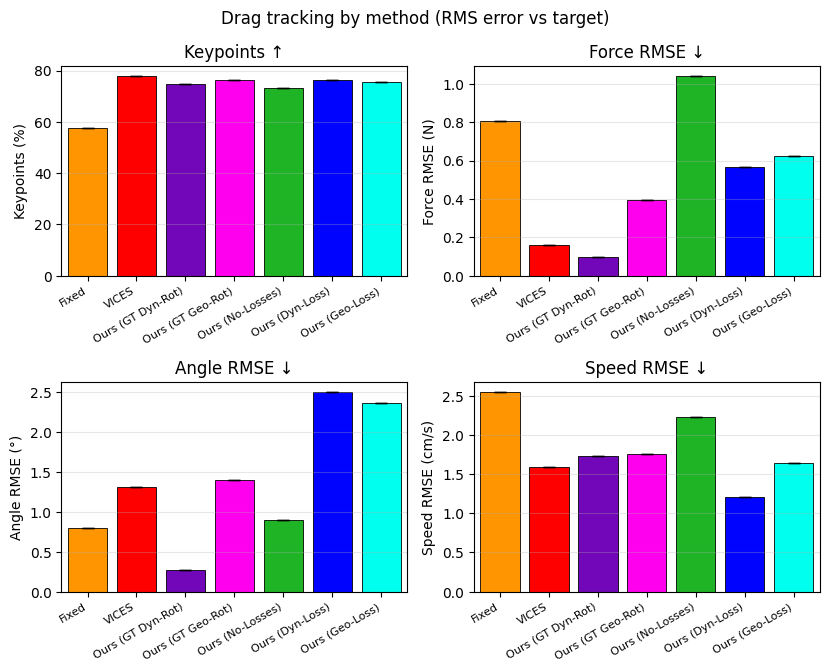

In [28]:
# Drag-metric bars — one subplot per metric, reusing the Block-4 TABLE_METRICS specs
# (tag/offset/scale/rms) so the bars match the summary table exactly. x = methods,
# y = value (RMS error vs target for force/angle/speed; % achieved for keypoints), 95% CI.
BAR_TAGS = [
    "drag_performance/keypoints_achieved_mean",
    "drag_performance/force_mean",
    "drag_performance/theta_mean",
    "drag_performance/speed_d_mean",
]
BAR_METRICS = [next(m for m in TABLE_METRICS if m["tag"] == t) for t in BAR_TAGS]
fig = pt.plot_metric_bars(DATA, BAR_METRICS, TABLE_GROUPS, STYLE, SELECTION_METRIC,
                          ncols=2, suptitle="Drag tracking by method (RMS error vs target)")
STYLE.save(fig, "drag_rmse_bars")
plt.show()